### Data Analysis EDA (only Green Taxi --> smallest download) 
- 2024 - January    ← pre-policy baseline (start of your study period)
- 2024 - June       ← mid pre-period check
- 2024 - December   ← right before policy kicks in
- 2025 - January    ← first month post-policy (CPZ in place January 5, 2025)
- 2025 - June       ← mid post-period

### EDA Summary: Green taxi's were already largely restricted from lower Manhattan (major CPZ zone). The congestion toll ($0.75/trip) may be too small to meaningfully in addition to their lack of volume travelling to zoned areas. Also this is a spread out sample, so perhaps mroe data will show otherwise.

- Green Taxi ~ 45,000 trips monthly | 0.75 CPZ per trip
- Yellow Taxi— much larger ~ 3 million trips monthly | 0.75 CPZ per trip
- FHV ~ 175,000 trips monthly | 0.75 CPZ per trip
- HVFHV — these files are huge (2-4GB each) ~ 20 million trips monthly | 1.50 CPZ per trip

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [21]:
# Importing green taxi data over 5 gaps specified about - this is just to get an overrall gist  
data_path = "../data/"

files = {
    "2024-01": "green_tripdata_2024-01.parquet", 
    "2024-06": "green_tripdata_2024-06.parquet", 
    "2024-12": "green_tripdata_2024-12.parquet",
    "2025-01": "green_tripdata_2025-01.parquet",
    "2025-06": "green_tripdata_2025-06.parquet",
}

frames = []
for month, filename in files.items():
    temp = pd.read_parquet(os.path.join(data_path, filename))
    temp["month_label"] = month
    frames.append(temp)

green_taxi = pd.concat(frames, ignore_index=True)

print(f"Total rows: {len(green_taxi):,}")
print(f"Columns: {green_taxi.columns.tolist()}")

Total rows: 263,009
Columns: ['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'month_label', 'cbd_congestion_fee']


In [23]:
green_taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263009 entries, 0 to 263008
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               263009 non-null  int32         
 1   lpep_pickup_datetime   263009 non-null  datetime64[us]
 2   lpep_dropoff_datetime  263009 non-null  datetime64[us]
 3   store_and_fwd_flag     250093 non-null  object        
 4   RatecodeID             250093 non-null  float64       
 5   PULocationID           263009 non-null  int32         
 6   DOLocationID           263009 non-null  int32         
 7   passenger_count        250093 non-null  float64       
 8   trip_distance          263009 non-null  float64       
 9   fare_amount            263009 non-null  float64       
 10  extra                  263009 non-null  float64       
 11  mta_tax                263009 non-null  float64       
 12  tip_amount             263009 non-null  floa

In [25]:
green_taxi.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
count,263009.000000,263009,263009,250093.000000,263009.000000,263009.000000,250093.000000,263009.000000,263009.000000,263009.000000,263009.000000,263009.000000,263009.000000,0.0,263009.000000,263009.000000,250093.000000,250059.000000,250093.000000,95880.000000
mean,1.904197,2024-10-06 23:48:57.733088,2024-10-07 00:08:30.256443,1.218087,95.718397,141.988088,1.302016,18.309437,17.896805,0.908396,0.581226,2.540834,0.216872,NaN,0.979949,23.921682,1.288149,1.045337,0.836498,0.064268
min,1.000000,2008-12-31 23:08:01,2009-01-01 00:07:45,1.000000,1.000000,1.000000,0.000000,0.000000,-250.080000,-7.500000,-0.500000,-1.660000,-6.940000,NaN,-1.000000,-251.080000,1.000000,1.000000,-2.750000,-0.750000
25%,2.000000,2024-06-05 20:27:20,2024-06-05 20:44:00,1.000000,74.000000,74.000000,1.000000,1.140000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,13.900000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,2024-12-11 19:20:43,2024-12-11 19:36:32,1.000000,75.000000,140.000000,1.000000,1.850000,13.500000,0.000000,0.500000,2.020000,0.000000,NaN,1.000000,19.200000,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2025-01-22 11:24:06,2025-01-22 11:42:01,1.000000,97.000000,229.000000,1.000000,3.200000,20.500000,1.000000,0.500000,3.780000,0.000000,NaN,1.000000,27.900000,2.000000,1.000000,2.750000,0.000000
max,6.000000,2025-07-01 20:35:08,2025-07-01 21:11:08,99.000000,265.000000,265.000000,9.000000,201421.680000,1422.600000,10.250000,4.250000,252.050000,49.940000,NaN,1.000000,1424.100000,5.000000,2.000000,2.750000,0.750000
std,0.468560,NaN,NaN,1.559332,56.524874,77.124582,0.969572,961.845442,16.562466,1.367422,0.361116,3.284935,1.301500,NaN,0.152125,18.645871,0.484971,0.208043,1.264560,0.209987


Averagingh around 1.3 passengers per trip

In [27]:
green_taxi.isnull().sum()

VendorID                      0
lpep_pickup_datetime          0
lpep_dropoff_datetime         0
store_and_fwd_flag        12916
RatecodeID                12916
PULocationID                  0
DOLocationID                  0
passenger_count           12916
trip_distance                 0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
ehail_fee                263009
improvement_surcharge         0
total_amount                  0
payment_type              12916
trip_type                 12950
congestion_surcharge      12916
month_label                   0
cbd_congestion_fee       167129
dtype: int64

- Core variables (lpep_pickup_datetime, PULocationID, DOLocationID, and trip_distance) zero nulls - good for our analysis. 
- cbd_congestion_fee is about halfway empty: policy was not in place for about half of the data provided.

In [31]:
# Parse datetime
green_taxi["pickup_dt"] = pd.to_datetime(df["lpep_pickup_datetime"])  # green uses lpep
green_taxi["trip_date"] = green_taxi["pickup_dt"].dt.date
green_taxi["hour"]      = green_taxi["pickup_dt"].dt.hour
green_taxi["month"]     = green_taxi["pickup_dt"].dt.to_period("M")

# Post-treatment flag — the key variable
green_taxi["post_treatment"] = green_taxi["pickup_dt"] >= "2025-01-05"

print(green_taxi[["pickup_dt", "trip_date", "post_treatment"]].head(10))

            pickup_dt   trip_date  post_treatment
0 2024-01-01 00:46:55  2024-01-01           False
1 2024-01-01 00:31:42  2024-01-01           False
2 2024-01-01 00:30:21  2024-01-01           False
3 2024-01-01 00:30:20  2024-01-01           False
4 2024-01-01 00:32:38  2024-01-01           False
5 2024-01-01 00:43:41  2024-01-01           False
6 2024-01-01 00:31:56  2024-01-01           False
7 2024-01-01 00:46:12  2024-01-01           False
8 2024-01-01 00:38:07  2024-01-01           False
9 2024-01-01 00:44:24  2024-01-01           False


In [41]:
# Load zone lookup
lookup = pd.read_csv(os.path.join(data_path, "taxi_zone_lookup.csv"))
lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [39]:
lookup["Borough"].unique()

array(['EWR', 'Queens', 'Bronx', 'Manhattan', 'Staten Island', 'Brooklyn',
       'Unknown', nan], dtype=object)

In [50]:
# Drop null boroughs
lookup = lookup.dropna(subset=["Borough"])

# See all Manhattan zones specifically
manhattan_zones = lookup[lookup["Borough"] == "Manhattan"]
print(manhattan_zones[["LocationID", "Zone"]].to_string())

     LocationID                                           Zone
3             4                                  Alphabet City
11           12                                   Battery Park
12           13                              Battery Park City
23           24                                   Bloomingdale
40           41                                 Central Harlem
41           42                           Central Harlem North
42           43                                   Central Park
44           45                                      Chinatown
47           48                                   Clinton East
49           50                                   Clinton West
67           68                                   East Chelsea
73           74                              East Harlem North
74           75                              East Harlem South
78           79                                   East Village
86           87                       Financial Distric

In [52]:
# Defining our CPZ zones 
upper_manhattan = [
    "Inwood", "Washington Heights North", "Washington Heights South",
    "Hamilton Heights", "Manhattanville", "Harlem", "East Harlem North",
    "East Harlem South", "Manhattan Valley", "Morningside Heights",
    "Central Harlem", "Central Harlem North"
]

cpz_zone_ids = lookup[
    (lookup["Borough"] == "Manhattan") &
    (~lookup["Zone"].isin(upper_manhattan))
]["LocationID"].tolist()

print(f"CPZ zone IDs: {cpz_zone_ids}")
print(f"Total CPZ zones: {len(cpz_zone_ids)}")

CPZ zone IDs: [4, 12, 13, 24, 43, 45, 48, 50, 68, 79, 87, 88, 90, 100, 103, 104, 105, 107, 113, 114, 120, 125, 128, 137, 140, 141, 142, 143, 144, 148, 153, 158, 161, 162, 163, 164, 170, 186, 194, 202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 246, 249, 261, 262, 263]
Total CPZ zones: 58


In [54]:
# Flag trips that touch the CPZ
green_taxi["in_cpz"] = (
    green_taxi["PULocationID"].isin(cpz_zone_ids) |
    green_taxi["DOLocationID"].isin(cpz_zone_ids)
)

green_taxi["zone_group"] = green_taxi["in_cpz"].map({True: "CPZ", False: "Non-CPZ"})

# Sanity check
print(green_taxi["zone_group"].value_counts())
print(f"\nCPZ trip %: {green_taxi['in_cpz'].mean()*100:.1f}%")

zone_group
Non-CPZ    170390
CPZ         92619
Name: count, dtype: int64

CPZ trip %: 35.2%


In [58]:
daily = (
    green_taxi.groupby(["trip_date", "zone_group", "post_treatment"])
    .size()
    .reset_index(name="trip_volume")
)

daily["trip_date"] = pd.to_datetime(daily["trip_date"])
print(daily.head(20))

    trip_date zone_group  post_treatment  trip_volume
0  2008-12-31    Non-CPZ           False            1
1  2009-01-01        CPZ           False            1
2  2023-12-31    Non-CPZ           False            2
3  2024-01-01        CPZ           False          386
4  2024-01-01    Non-CPZ           False          803
5  2024-01-02        CPZ           False          551
6  2024-01-02    Non-CPZ           False         1117
7  2024-01-03        CPZ           False          602
8  2024-01-03    Non-CPZ           False         1188
9  2024-01-04        CPZ           False          719
10 2024-01-04    Non-CPZ           False         1382
11 2024-01-05        CPZ           False          705
12 2024-01-05    Non-CPZ           False         1414
13 2024-01-06        CPZ           False          486
14 2024-01-06    Non-CPZ           False         1142
15 2024-01-07        CPZ           False          304
16 2024-01-07    Non-CPZ           False          825
17 2024-01-08        CPZ    

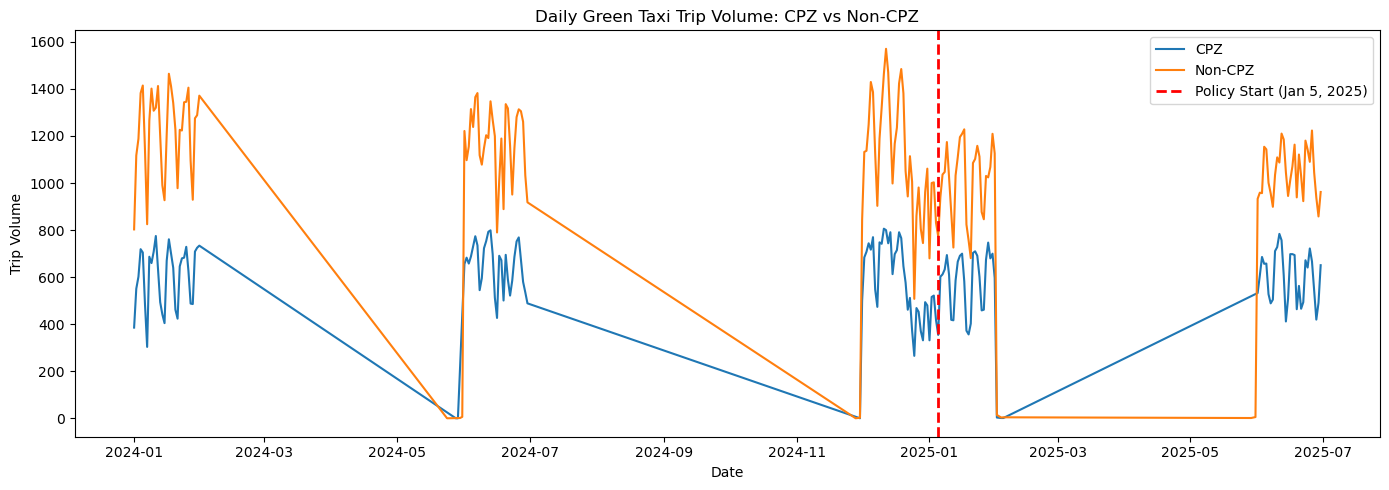

In [62]:
# Diagonals are from the data we do not have already
# Filter to your study period only
daily = daily[
    (daily["trip_date"] >= "2024-01-01") &
    (daily["trip_date"] <= "2025-06-30")
]

# Then replot
fig, ax = plt.subplots(figsize=(14, 5))

for group, subset in daily.groupby("zone_group"):
    ax.plot(subset["trip_date"], subset["trip_volume"], label=group)

ax.axvline(pd.Timestamp("2025-01-05"), 
           color="red", linestyle="--", linewidth=2,
           label="Policy Start (Jan 5, 2025)")

ax.set_title("Daily Green Taxi Trip Volume: CPZ vs Non-CPZ")
ax.set_xlabel("Date")
ax.set_ylabel("Trip Volume")
ax.legend()
plt.tight_layout()
plt.show()

Preliminary exploration of 5 sampled months suggests CPZ trip share remained relatively stable around 33-36%. This isn't a big change post policy, but it may be connected to the fact that cpz rides for the green taxis are relatively small ~ $0.75 per trip. 

In [76]:
# Key Table!!!
# Compare CPZ share per month to control for unequal month counts
monthly_share = (
    green_taxi.groupby("month_label")["in_cpz"]
    .mean() * 100
).reset_index()

monthly_share.columns = ["month", "cpz_share_pct"]
monthly_share["post"] = monthly_share["month"] >= "2025-01"
print(monthly_share)

     month  cpz_share_pct   post
0  2024-01      33.109936  False
1  2024-06      35.648791  False
2  2024-12      34.818684  False
3  2025-01      36.249638   True
4  2025-06      36.566106   True


In [72]:
print(green_taxi.groupby(["post_treatment", "zone_group"]).size().unstack())

zone_group        CPZ  Non-CPZ
post_treatment                
False           58826   111764
True            33793    58626
